In [1]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
from face_dataset import process_pixels, FaceDataset

Data Loading: Read the CSV and inspected the raw pixels strings.

In [2]:
# Load the dataset
df = pd.read_csv('./data/age_gender.csv')

print(df.head())
print(df.columns)

   age  ethnicity  gender                        img_name  \
0    1          2       0  20161219203650636.jpg.chip.jpg   
1    1          2       0  20161219222752047.jpg.chip.jpg   
2    1          2       0  20161219222832191.jpg.chip.jpg   
3    1          2       0  20161220144911423.jpg.chip.jpg   
4    1          2       0  20161220144914327.jpg.chip.jpg   

                                              pixels  
0  129 128 128 126 127 130 133 135 139 142 145 14...  
1  164 74 111 168 169 171 175 182 184 188 193 199...  
2  67 70 71 70 69 67 70 79 90 103 116 132 145 155...  
3  193 197 198 200 199 200 202 203 204 205 208 21...  
4  202 205 209 210 209 209 210 211 212 214 218 21...  
Index(['age', 'ethnicity', 'gender', 'img_name', 'pixels'], dtype='str')


Preprocessing: Create a function to split, convert, and reshape strings to $48 \times 48$.

Image shape: (48, 48)


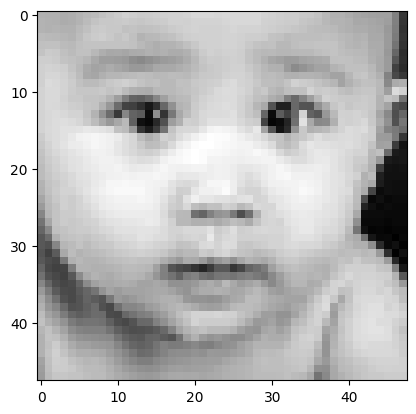

In [3]:
# Test it on the first row of the DataFrame
test_img = process_pixels(df['pixels'][0])
print(f"Image shape: {test_img.shape}")

# Visualize one to make sure it looks like a face
plt.imshow(test_img, cmap='gray')
plt.show()

Spliting: Divided the data into three distinct buckets.

In [4]:
from sklearn.model_selection import train_test_split

# 1. First split: 80% for training, 20% for a "temporary" set
train_df, temp_df = train_test_split(df, test_size=0.2, random_state=42)

# 2. Second split: Split that 20% into two equal 10% halves (Validation and Test)
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42)

print(f"Training rows: {len(train_df)}")
print(f"Validation rows: {len(val_df)}")
print(f"Testing rows: {len(test_df)}")

Training rows: 18964
Validation rows: 2370
Testing rows: 2371


Data pipeline: Built a custom Dataset and DataLoader for batching.

In [5]:
train_dataset = FaceDataset(train_df)
val_dataset = FaceDataset(val_df)
test_dataset = FaceDataset(test_df)

In [6]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False)

Model Architecture

One small technical hurdle: mobilenet_v3_large expects 3-channel (RGB) images, but our data is 1-channel (Grayscale).

To fix this without changing the model's complex internal architecture, we can simply "repeat" our grayscale channel three times right before we feed it into the model.

In PyTorch, we can use .repeat(1, 3, 1, 1) on a batch of images to turn a shape of (Batch, 1, 48, 48) into (Batch, 3, 48, 48).

In the multi-task model, we will actually have three different losses running at the same time:

1. Age Loss: nn.MSELoss() (calculates the distance between numbers).

2. Gender Loss: nn.CrossEntropyLoss() (binary classification).

3. Ethnicity Loss: nn.CrossEntropyLoss() (multi-class classification).

During training, we sum these together to get a Total Loss that tells the model how it's doing across all three tasks.

Optimization Phase: 

Loss Weighting & LR SchedulingObservation: Initially, the Total Loss was dominated by the Age prediction ($Loss \approx 181$). Because the Gender and Ethnicity losses were much smaller ($Loss < 1.5$), the model was effectively "ignoring" them to focus on the age numbers.

📉What we are adding:
- Loss Weighting ⚖️: We are multiplying the classification losses by a factor (e.g., $10 \times$ for Gender) to give them more "importance" in the gradient calculation. This balances the tug-of-war between the three heads.
- Learning Rate Scheduler 📉: We are adding a ReduceLROnPlateau scheduler. This watches our validation metrics and "slows down" the learning rate when progress stalls, helping the model settle into its most accurate state.

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from model import FaceAnalysisModel
from tqdm import tqdm

# 2. Setup Device, Model, and Freezing
# Instantiate
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
model = FaceAnalysisModel(backbone_requires_grad=True).to(device)

# Define three distinct Loss Functions
criterion_age = nn.MSELoss()
criterion_gender = nn.CrossEntropyLoss()
criterion_ethnicity = nn.CrossEntropyLoss()

# Optimizer (only tracking the parameters that aren't frozen)
optimizer = optim.AdamW((p for p in model.parameters() if p.requires_grad), lr=1e-3, weight_decay=1e-4)

# 4. Training Step (Inside your training loop)
def train_one_epoch(epoch):
    model.train()
    running_loss = 0.0
    running_age = 0.0
    running_gender = 0.0
    running_ethnicity = 0.0
    num_batches = 0

    for images, labels in tqdm(train_dataloader, desc=f"Training epoch {epoch}"):
        optimizer.zero_grad()

        images = images.to(device)
        # Move labels to device
        age_targets = labels["age"].to(device).float().unsqueeze(1)
        gender_targets = labels["gender"].to(device).long()
        ethnicity_targets = labels["ethnicity"].to(device).long()

        # Forward
        out_age, out_gender, out_ethnicity = model(images)

        # Calculate Losses
        loss_a = criterion_age(out_age, age_targets)
        loss_g = criterion_gender(out_gender, gender_targets)
        loss_e = criterion_ethnicity(out_ethnicity, ethnicity_targets)

        # Sum and Backprop
        # loss = loss_a + loss_g + loss_e

        # Giving more weight to classification tasks
        # Adjust these coefficients based on your logs
        loss = loss_a + (10.0 * loss_g) + (5.0 * loss_e)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_age += loss_a.item()
        running_gender += loss_g.item()
        running_ethnicity += loss_e.item()
        num_batches += 1

    return (
        running_loss / num_batches,
        running_age / num_batches,
        running_gender / num_batches,
        running_ethnicity / num_batches,
    )

@torch.no_grad()
def validate():
    model.eval()
    age_abs_errors = []
    total_samples = 0
    correct_gender = 0
    correct_ethnicity = 0

    for images, labels in val_dataloader:
        images = images.to(device)
        # Move labels to device
        age_targets = labels["age"].to(device).float().unsqueeze(1)
        gender_targets = labels["gender"].to(device).long()
        ethnicity_targets = labels["ethnicity"].to(device).long()

        # Forward
        out_age, out_gender, out_ethnicity = model(images)

        # Calculate Losses
        age_abs_errors.append(torch.abs(out_age - age_targets).mean().item())
        correct_gender += (out_gender.argmax(dim=1) == gender_targets).sum().item()
        correct_ethnicity += (out_ethnicity.argmax(dim=1) == ethnicity_targets).sum().item()
        total_samples += images.size(0)

    age_mae = float(np.mean(age_abs_errors))
    gender_acc = 100.0 * correct_gender / total_samples
    ethnicity_acc = 100.0 * correct_ethnicity / total_samples
    return age_mae, gender_acc, ethnicity_acc

# 1. Define the Scheduler after the Optimizer
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, 
    mode='min',    # We want to MINIMIZE the error
    factor=0.2,    # Multiply LR by 0.2 (reduce by 80%)
    patience=3,    # Wait 3 epochs before reducing
    # verbose=True
)

epochs = 30
for epoch in range(epochs):
    train_loss, age_loss, gender_loss, ethnicity_loss = train_one_epoch(epoch)
    age_mae, gender_acc, ethnicity_acc = validate()

    # 2. Update the scheduler at the end of every epoch
    scheduler.step(age_mae)

    print(f"Current LR: {optimizer.param_groups[0]['lr']}")
    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Age Loss: {age_loss:.4f} | Gender Loss: {gender_loss:.4f} | Ethnicity Loss: {ethnicity_loss:.4f} | "
        f"Val MAE: {age_mae:.4f} | Gender Acc: {gender_acc:.2f}% | Ethnicity Acc: {ethnicity_acc:.2f}%"
    )
    

Training epoch 0: 100%|██████████| 593/593 [00:42<00:00, 13.93it/s]


Current LR: 0.001
Epoch 1/30 | Train Loss: 188.6710 | Age Loss: 177.5399 | Gender Loss: 0.5057 | Ethnicity Loss: 1.2149 | Val MAE: 8.8305 | Gender Acc: 75.78% | Ethnicity Acc: 58.52%


Training epoch 1: 100%|██████████| 593/593 [00:39<00:00, 15.00it/s]


Current LR: 0.001
Epoch 2/30 | Train Loss: 99.4913 | Age Loss: 90.0464 | Gender Loss: 0.4083 | Ethnicity Loss: 1.0723 | Val MAE: 6.4217 | Gender Acc: 80.38% | Ethnicity Acc: 61.73%


Training epoch 2: 100%|██████████| 593/593 [00:39<00:00, 15.00it/s]


...

Current LR: 3.200000000000001e-07
Epoch 28/30 | Train Loss: 9.2146 | Age Loss: 5.3443 | Gender Loss: 0.1339 | Ethnicity Loss: 0.5062 | Val MAE: 5.4997 | Gender Acc: 90.21% | Ethnicity Acc: 74.85%


Training epoch 28: 100%|██████████| 593/593 [00:39<00:00, 14.94it/s]


Current LR: 3.200000000000001e-07
Epoch 29/30 | Train Loss: 9.1064 | Age Loss: 5.2593 | Gender Loss: 0.1320 | Ethnicity Loss: 0.5054 | Val MAE: 5.5010 | Gender Acc: 90.30% | Ethnicity Acc: 75.11%


Training epoch 29: 100%|██████████| 593/593 [00:40<00:00, 14.72it/s]


Current LR: 3.200000000000001e-07
Epoch 30/30 | Train Loss: 9.0660 | Age Loss: 5.2238 | Gender Loss: 0.1323 | Ethnicity Loss: 0.5038 | Val MAE: 5.4976 | Gender Acc: 90.08% | Ethnicity Acc: 75.19%


 Training Observations & Analysis
 
 1. Impact of Loss Weighting ⚖️: By applying weights to the classification losses ($10.0 \times$ Gender and $5.0 \times$ Ethnicity), we effectively balanced the "tug-of-war" between the three tasks.
- Result: The Gender Accuracy increased from ~86% to ~90%, and Ethnicity Accuracy jumped from ~67% to ~75%. This confirms that the model is now paying significantly more attention to these heads than it did in the initial run.
2. Scheduler Efficiency 📉: The ReduceLROnPlateau scheduler successfully identified "plateaus" where progress stalled.
- Result: Around Epoch 10, the learning rate dropped from 0.001 to 0.0002. This "slow down" allowed the model to fine-tune its weights, immediately leading to a significant drop in Val MAE from 6.0 to 5.35 in the very next epoch.
3. Generalization vs. Overfitting 🧠: While the training loss continued to drop, the Validation MAE eventually stabilized around 5.5 years. This suggests the model has reached its current capacity for age prediction given the $48 \times 48$ resolution of the input images.

In [9]:
# Saving the model
torch.save(model.state_dict(), 'face_cnn.pth')

In [10]:
# Load the model again
model = FaceAnalysisModel(backbone_requires_grad=False)
model.load_state_dict(torch.load("face_cnn.pth"))
model

FaceAnalysisModel(
  (backbone): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, track_running_stats=True)
        )
      )
    )
    (2): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 64, kernel_size=(1, 1), stride=(1, 

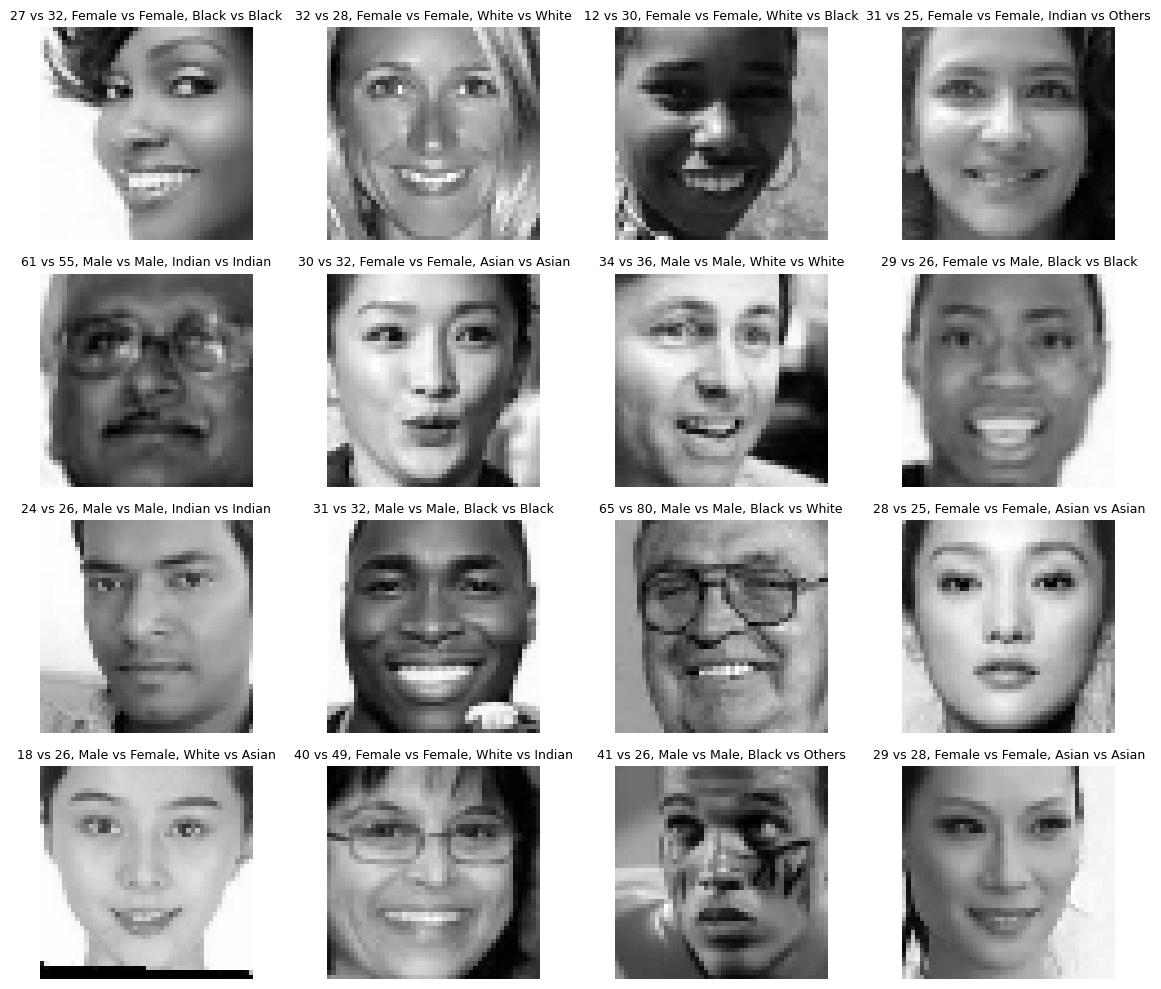

In [11]:
import matplotlib.pyplot as plt

# 1. Define the human-readable labels
genders= ["Male", "Female"]
ethnicities = ["White", "Black", "Asian", "Indian", "Others"]

# 2. Grab a single batch of images from the test loader
images, labels = next(iter(test_dataloader))

# 3. Get predictions for that batch
model.eval() # Set model to evaluation mode
preds = []
with torch.no_grad():
    outputs = model(images)
    age, gender, ethnicity = outputs
    gender = gender.argmax(dim=1)
    ethnicity = ethnicity.argmax(dim=1)
    for j in range(len(age)):
        preds.append((age[j].item(), gender[j].item(), ethnicity[j].item()))

# 4. Plot the first 6 images
plt.figure(figsize=(12, 10))
for i in range(16):
    plt.subplot(4, 4, i + 1)
    
    # Clean up the image for display (28x28)
    img = images[i].squeeze()
    plt.imshow(img, cmap="gray")
    
    age_pred, gender_pred, eth_pred = preds[i]
    age_label, gender_label, eth_label = labels['age'][i].item(), labels['gender'][i].item(), labels['ethnicity'][i].item()
    plt.title(f"{age_pred:.0f} vs {age_label:.0f}, {genders[gender_pred]} vs {genders[gender_label]}, {ethnicities[eth_pred]} vs {ethnicities[eth_label]}", fontsize=9)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix
import numpy as np

all_gender_preds = []
all_gender_labels = []
all_ethnicity_preds = []
all_ethnicity_labels = []

model.eval()
with torch.no_grad():
    for images, labels in tqdm(test_dataloader):
        outputs = model(images)
        age, gender, ethnicity = outputs
        gender = gender.argmax(dim=1)
        ethnicity = ethnicity.argmax(dim=1)
        
        # Move to CPU and convert to numpy for sklearn
        all_gender_preds.extend(gender.cpu().numpy())
        all_gender_labels.extend(labels['gender'].cpu().numpy())

        all_ethnicity_preds.extend(ethnicity.cpu().numpy())
        all_ethnicity_labels.extend(labels['ethnicity'].cpu().numpy())

In [ ]:
confusion_matrix(all_gender_labels, all_gender_preds)

In [ ]:
import itertools

def plot_confusion_matrix(cm, classes, cmap=plt.cm.Blues):
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title("Confusion Matrix")
    plt.colorbar()
    
    # Add labels to the axes
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    # Add the counts inside each cell
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.tight_layout()
    plt.ylabel('True label')
    plt.xlabel('Predicted label')

# Run the plotting function
plt.figure(figsize=(10, 10))
plot_confusion_matrix(confusion_matrix(all_gender_labels, all_gender_preds), genders)
plt.show()

In [ ]:
plt.figure(figsize=(10, 10))
plot_confusion_matrix(confusion_matrix(all_ethnicity_labels, all_ethnicity_preds), ethnicities)
plt.show()